## Polytope Climate-DT Country pcolormesh example notebook

This notebook shows how to use earthkit-data and earthkit-plots to pull destination-earth data from LUMI and plot it using earthkit-plots using pcolormesh and contourf.

Before running the notebook you need to set up your credentials. See the main readme of this repository for different ways to do this or use the following cells to authenticate.

You will need to generate your credentials using the desp-authentication.py script.

This can be run as follows:

In [ ]:
%%capture cap
%run ../../desp-authentication.py

This will generate a token that can then be used by earthkit and polytope.

In [ ]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

# Requirements
To run this notebook install the following:
* pip install earthkit-data
* pip install earthkit-plots
* pip install earthkit-geo
* pip install earthkit-regrid  (Optional for spectral variables)
* pip install cf-units         (Optional for unit conversion in maps)

If you do not have eccodes installed please install eccodes using conda as it is a dependency of earthkit, or install earthkit via conda

* conda install eccodes -c conda-forge
* conda install earthkit-data -c conda-forge

In [ ]:
import earthkit.data
import earthkit.plots
from earthkit.plots.resample import Interpolate
import earthkit.geo.cartography
import numpy as np

In [ ]:
# Defaults to making a live data request. Set to false to use the cached GRIB file instead.
import os

LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"
LIVE_REQUEST

In [ ]:
countries = ["France", "Poland"] # List of countries

shapes = earthkit.geo.cartography.country_polygons(countries, resolution=50e6)

request = {
    "activity": "projections",
    "class": "d1",
    "dataset": "climate-dt",
    "experiment": "ssp3-7.0",
    "generation": "2",
    "levtype": "sfc",
    "date": "20400102",
    "model": "ifs-nemo",
    "expver": "0001",
    "param": "167/165",
    "realization": "1",
    "resolution": "standard",
    "stream": "clte",
    "type": "fc",
    "time": "1200",
    "feature": {
        "type": "polygon",
        "shape": shapes
    },
}

In [ ]:
data_file = "../data/climate-dt-earthkit-fe-pcolormesh.covjson"
if LIVE_REQUEST:
    data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.mn5.apps.dte.destination-earth.eu", stream=False)
    with open(data_file, "w") as _f:
        data.to_target("file", _f)
else:
    data = earthkit.data.from_source("file", data_file) 

In [ ]:
ds = data.to_xarray()
ds

<xarray.Dataset> Size: 16kB
Dimensions:    (datetimes: 1, number: 1, steps: 1, points: 329)
Coordinates:
  * datetimes  (datetimes) <U20 80B '2040-01-02 12:00:00Z'
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 3kB 0 1 2 3 4 5 6 ... 322 323 324 325 326 327 328
    latitude   (points) float64 3kB 41.41 41.81 42.21 ... 54.34 54.34 54.72
    longitude  (points) float64 3kB 9.141 8.789 8.858 ... 22.03 22.97 17.53
    levelist   (points) float64 3kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    10u        (datetimes, number, steps, points) float64 3kB -5.558 ... 7.583
    2t         (datetimes, number, steps, points) float64 3kB 284.9 ... 280.4
Attributes: (12/15)
    activity:     projections
    class:        d1
    dataset:      climate-dt
    experiment:   ssp3-7.0
    expver:       0001
    generation:   2
    ...           ...
    resolution:   standard
    stream:       clte
    type:         fc
    number:       0
    step:         0
    date:         2040-01-02 12:00:00Z

In [ ]:
lats = ds.latitude.values
lons = ds.longitude.values
values = ds["2t"].values.squeeze()

# Pre-interpolate unstructured data onto a regular grid
interpolator = Interpolate(distance_threshold="auto")
lons_grid, lats_grid, values_grid = interpolator.apply(lons, lats, values)

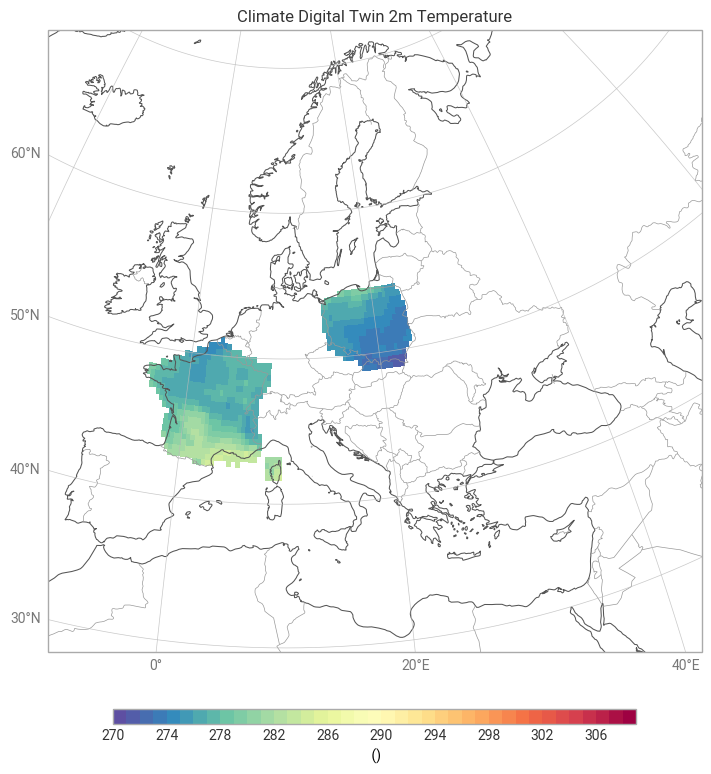

In [ ]:
chart = earthkit.plots.Map(domain=["Europe"])
style = earthkit.plots.styles.Style(
    levels=np.arange(270, 310, 1),
    colors="Spectral_r",
)
chart.pcolormesh(
    x=lons_grid, y=lats_grid, z=values_grid, style=style, units="celsius"
)

chart.coastlines()
chart.borders()
chart.gridlines()

chart.title("Climate Digital Twin 2m Temperature")

chart.legend()

chart.show()

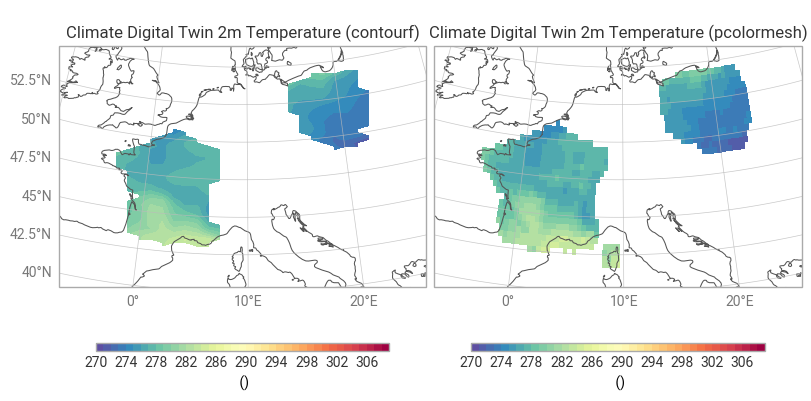

In [ ]:
figure = earthkit.plots.Figure(rows=1, columns=2, domain=["France", "Poland"])
style = earthkit.plots.styles.Style(
    levels=np.arange(270, 310, 1),
    colors="Spectral_r",
)

chart = figure.add_map()
chart.contourf(
    x=lons_grid, y=lats_grid, z=values_grid, style=style,
)
chart.legend()
chart.title("Climate Digital Twin 2m Temperature (contourf)")

chart = figure.add_map()
chart.pcolormesh(
    x=lons_grid, y=lats_grid, z=values_grid, style=style,
)
chart.legend()
chart.title("Climate Digital Twin 2m Temperature (pcolormesh)")

figure.coastlines()
figure.gridlines()